
 SIFT
Keypoints: 236 174 Matches: 8


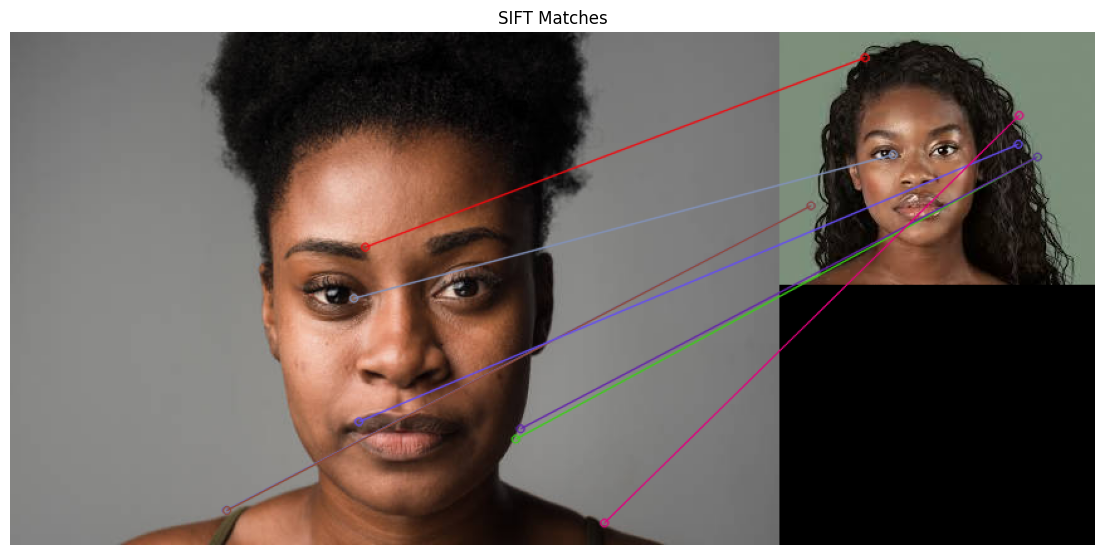


 ORB
Keypoints: 1039 696 Matches: 14


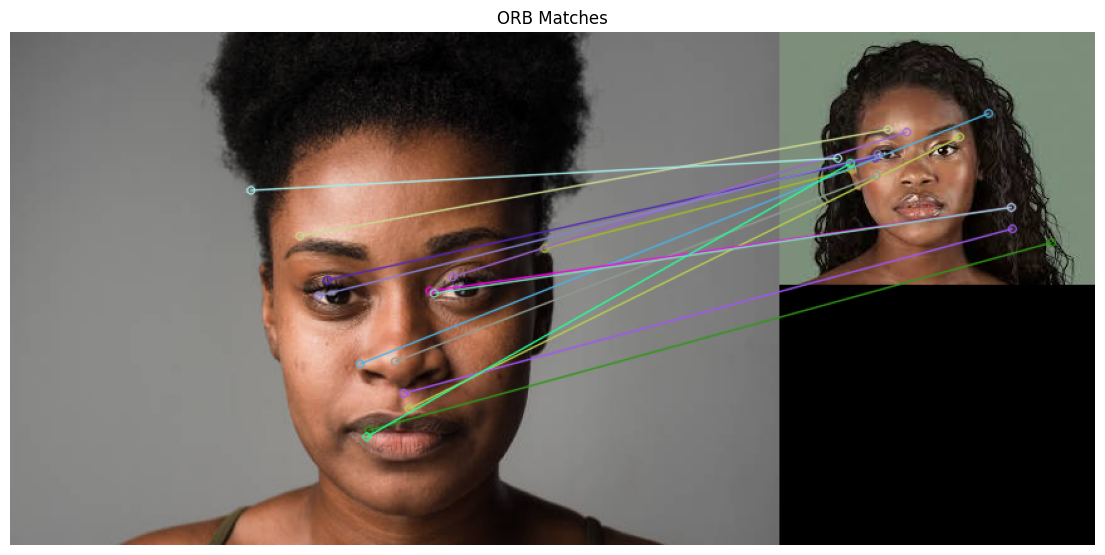


SURF: 
SURF not available (non-free module missing)
SURF not available (non-free module missing)
Skipping SURF matching


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# ─────────────── IMAGE LOADING ───────────────

def load_and_prepare_image(image_path):
    img_color = cv2.imread(image_path)
    if img_color is None:
        raise FileNotFoundError(f"Cannot load image: {image_path}")
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    return img_color, img_gray


# ─────────────── FEATURE DETECTORS ───────────────

def detect_and_compute_sift(gray_img):
    sift = cv2.SIFT_create()
    return sift.detectAndCompute(gray_img, None)


def detect_and_compute_orb(gray_img, nfeatures=2000):
    orb = cv2.ORB_create(nfeatures=nfeatures)
    return orb.detectAndCompute(gray_img, None)


def detect_and_compute_surf(gray_img):
    try:
        surf = cv2.xfeatures2d.SURF_create(400)
        return surf.detectAndCompute(gray_img, None)
    except:
        print("SURF not available (non-free module missing)")
        return [], None


# ─────────────── MATCHING ───────────────

def match_features(des1, des2, method="sift", ratio=0.75):
    if des1 is None or des2 is None:
        return []

    if method.lower() in ["sift", "surf"]:
        matcher = cv2.BFMatcher(cv2.NORM_L2)
    else:
        matcher = cv2.BFMatcher(cv2.NORM_HAMMING)

    matches = matcher.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < ratio * n.distance:
            good.append(m)

    return good


def draw_matches(img1, kp1, img2, kp2, matches, title):
    matched_img = cv2.drawMatches(
        img1, kp1, img2, kp2, matches, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


# ─────────────── MAIN PIPELINE ───────────────

def main():
    img1_path = "image1.jpg"
    img2_path = "image2.jpeg"

    img1_color, img1_gray = load_and_prepare_image(img1_path)
    img2_color, img2_gray = load_and_prepare_image(img2_path)

    # ────────────── SIFT ──────────────
    print("\n SIFT")
    kp1, des1 = detect_and_compute_sift(img1_gray)
    kp2, des2 = detect_and_compute_sift(img2_gray)
    matches = match_features(des1, des2, method="sift")
    print("Keypoints:", len(kp1), len(kp2), "Matches:", len(matches))
    draw_matches(img1_color, kp1, img2_color, kp2, matches, "SIFT Matches")

    # ────────────── ORB ──────────────
    print("\n ORB")
    kp1, des1 = detect_and_compute_orb(img1_gray)
    kp2, des2 = detect_and_compute_orb(img2_gray)
    matches = match_features(des1, des2, method="orb")
    print("Keypoints:", len(kp1), len(kp2), "Matches:", len(matches))
    draw_matches(img1_color, kp1, img2_color, kp2, matches, "ORB Matches")

    # ────────────── SURF ──────────────
    print("\nSURF: ")
    kp1, des1 = detect_and_compute_surf(img1_gray)
    kp2, des2 = detect_and_compute_surf(img2_gray)

    if des1 is not None and des2 is not None:
        matches = match_features(des1, des2, method="surf")
        print("Keypoints:", len(kp1), len(kp2), "Matches:", len(matches))
        draw_matches(img1_color, kp1, img2_color, kp2, matches, "SURF Matches")
    else:
        print("Skipping SURF matching")


if __name__ == "__main__":
    main()
